## Andria Linfante
### BINF 5312 Spring 2025
### Term Project - Sentiment Analysis
Due 4/22/25

### Importing Libraries & Initalize NLP Tools

In [ ]:
import pandas as pd
import nltk
import re
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [ ]:
pd.set_option('display.width', 180)

In [ ]:
nltk.download('vader_lexicon')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
# Initialize NLP tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
sia = SentimentIntensityAnalyzer()

## Load Dataset

In [ ]:
df = pd.read_csv('psych_drug_webmd_reviews.csv')
print(df.head(2))

   Unnamed: 0        drug_name       date    age  gender            time_on_drug reviewer_type                      condition  rating_overall  rating_effectiveness  \
0           0  Sertraline Oral  5/12/2024  45-54  Female  1 to less than 2 years       Patient  Posttraumatic Stress Syndrome             5.0                     5   
1           1  Sertraline Oral  4/21/2024  35-44  Female       less than 1 month       Patient                     Depression             1.0                     1   

   rating_ease_of_use  rating_satisfaction                                               text  
0                   5                    5  It's almost two years now and it has been so e...  
1                   1                    1  Iv been on this 4 weeks and iv never felt so a...  


## Preprocessing

In [ ]:
# Drop missing values
df = df.dropna(subset=['text'])
# Drop rows with no 'condition'
df = df.loc[(df['condition'] != 'Other') & (df['condition'] != '')]

In [ ]:
# Function for text preprocessing
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Tokenization
    tokens = word_tokenize(text)
    # Lemmatization & stopword removal
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

In [ ]:
# Apply preprocessing
df['cleaned_text'] = df['text'].apply(preprocess_text)
df['drug_name_first_word'] = df['drug_name'].str.split().str[0]
df.head(2)

,Unnamed: 0,drug_name,date,age,gender,time_on_drug,reviewer_type,condition,rating_overall,rating_effectiveness,rating_ease_of_use,rating_satisfaction,text,cleaned_text,drug_name_first_word
0,0,Sertraline Oral,5/12/2024,45-54,Female,1 to less than 2 years,Patient,Posttraumatic Stress Syndrome,5.0,5,5,5,It's almost two years now and it has been so e...,almost two year effective havent overthinking ...,Sertraline
1,1,Sertraline Oral,4/21/2024,35-44,Female,less than 1 month,Patient,Depression,1.0,1,1,1,Iv been on this 4 weeks and iv never felt so a...,iv week iv never felt angry irritable stressed...,Sertraline


## Perform VADER Sentiment Analysis

In [ ]:
# Function to get sentiment score
def get_vader_sentiment(text):
    score = sia.polarity_scores(text)
    return 'positive' if score['compound'] > 0.05 else 'negative' if score['compound'] < -0.05 else 'neutral'

In [ ]:
# Apply VADER sentiment analysis
df['vader_sentiment'] = df['cleaned_text'].apply(get_vader_sentiment)

## Save Analysis to New File

In [ ]:
# Create new DF with columns to keep for semtiment analysis review
columns_to_keep = ['condition', 'drug_name_first_word', 'rating_overall', 'rating_effectiveness',
                   'rating_ease_of_use', 'rating_satisfaction', 'vader_sentiment']

# Create final DataFrame
final_df = df[columns_to_keep]

In [ ]:
# Save to CSV
final_df.to_csv('sentiment_results.csv', index=False)

In [ ]:
print("Sentiment analysis completed and saved to sentiment_results.csv")

Sentiment analysis completed and saved to sentiment_results.csv


In [ ]:
# Verify data saved correctly
sentiment_df = pd.read_csv('sentiment_results.csv')
print(sentiment_df.head())

                       condition drug_name_first_word  rating_overall  rating_effectiveness  rating_ease_of_use  rating_satisfaction vader_sentiment
0  Posttraumatic Stress Syndrome           Sertraline             5.0                     5                   5                    5        positive
1                     Depression           Sertraline             1.0                     1                   1                    1        positive
2   Repeated Episodes of Anxiety           Sertraline             4.3                     4                   4                    5        negative
3                 Panic Disorder           Sertraline             1.7                     1                   3                    1        negative
4      Major Depressive Disorder           Sertraline             3.0                     2                   4                    3         neutral


## Statistical Analysis

In [ ]:
# Convert sentiment categories to numerical scores for averaging
sentiment_summary = sentiment_df.groupby("vader_sentiment").agg(
    avg_rating_overall=("rating_overall", "mean"),
    avg_rating_effectiveness=("rating_effectiveness", "mean"),
    avg_rating_ease_of_use=("rating_ease_of_use", "mean"),
    avg_rating_satisfaction=("rating_satisfaction", "mean"),
    count=("vader_sentiment", "count")
).reset_index()

print(sentiment_summary)

  vader_sentiment  avg_rating_overall  avg_rating_effectiveness  avg_rating_ease_of_use  avg_rating_satisfaction  count
0        negative            3.415265                  3.329238                3.981906                 2.936484  23931
1         neutral            3.528833                  3.388077                4.018093                 3.179773   4311
2        positive            4.030159                  3.977486                4.405000                 3.707469  19321


In [ ]:
# Evaluate if there is a colrrelation between condition and sentiment
condition_summary = df.groupby(["condition", "vader_sentiment"]).agg(
    avg_rating_overall=("rating_overall", "mean"),
    count=("condition", "count")
).reset_index()

print(condition_summary)

                                             condition vader_sentiment  avg_rating_overall  count
0    A Feeling of Restlessness with Inability to Si...        negative            4.616667      6
1    A Feeling of Restlessness with Inability to Si...        positive            4.700000      1
2             A Rare Developmental Disorder of Infants        negative            1.300000      1
3             A Rare Developmental Disorder of Infants         neutral            3.575000      4
4             A Rare Developmental Disorder of Infants        positive            3.433333      3
..                                                 ...             ...                 ...    ...
301                        Ventricular Premature Beats        positive            5.000000      1
302                         Welt from Pressure on Skin        negative            4.233333      3
303                         Welt from Pressure on Skin         neutral            3.500000      4
304                 

In [ ]:
# Evaluate if there is a colrrelation between drug and sentiment
drug_summary = df.groupby(["drug_name_first_word", "vader_sentiment"]).agg(
    avg_rating_overall=("rating_overall", "mean"),
    count=("drug_name_first_word", "count")
).reset_index()

print(drug_summary)

    drug_name_first_word vader_sentiment  avg_rating_overall  count
0                Abilify        negative            3.039297    626
1                Abilify         neutral            3.400000    145
2                Abilify        positive            3.783843    687
3             Acebutolol        negative            4.450000      6
4             Acebutolol        positive            4.650000      2
..                   ...             ...                 ...    ...
346                Zyban         neutral            3.957143      7
347                Zyban        positive            4.763636     22
348              Zyprexa        negative            2.670213    141
349              Zyprexa         neutral            3.096226     53
350              Zyprexa        positive            3.801005    199

[351 rows x 4 columns]


In [ ]:
# Export each analysis to its own CSV
sentiment_summary.to_csv("sentiment_summary.csv", index=False)
condition_summary.to_csv("condition_summary.csv", index=False)
drug_summary.to_csv("drug_summary.csv", index=False)

print("Statistiacl analyses completed and saved to sentiment_summary.csv ; condition_summary.csv ; drug_summary.csv")

Statistiacl analyses completed and saved to sentiment_summary.csv ; condition_summary.csv ; drug_summary.csv


In [ ]:
# Get the top 15 conditions with the most reviews
top_conditions = condition_summary.groupby("condition").agg(
    review_count=("count", "sum")
).sort_values("review_count", ascending=False).head(15).index.tolist()

# Filter the condition summary for the top 15 conditions
top_condition_summary = condition_summary[condition_summary["condition"].isin(top_conditions)]

print(top_condition_summary)

                                             condition vader_sentiment  avg_rating_overall  count
14          Additional Medications to Treat Depression        negative            2.969693    782
15          Additional Medications to Treat Depression         neutral            3.189637    193
16          Additional Medications to Treat Depression        positive            3.724227    776
33                                             Anxious        negative            3.769107   1434
34                                             Anxious         neutral            3.658951    324
35                                             Anxious        positive            4.201257   1432
36              Anxiousness associated with Depression        negative            3.765185    810
37              Anxiousness associated with Depression         neutral            3.660135    148
38              Anxiousness associated with Depression        positive            4.183582    603
50                  

In [ ]:
# Get the top 15 drugs with the most reviews
top_drugs = drug_summary.groupby("drug_name_first_word").agg(
    review_count=("count", "sum")
).sort_values("review_count", ascending=False).head(15).index.tolist()

# Filter the drug summary for the top 15 drugs
top_drug_summary = drug_summary[drug_summary["drug_name_first_word"].isin(top_drugs)]

print(top_drug_summary)

    drug_name_first_word vader_sentiment  avg_rating_overall  count
0                Abilify        negative            3.039297    626
1                Abilify         neutral            3.400000    145
2                Abilify        positive            3.783843    687
7             Alprazolam        negative            4.328835   1082
8             Alprazolam         neutral            3.948659    261
9             Alprazolam        positive            4.378388    819
47             Bupropion        negative            3.143993    566
48             Bupropion         neutral            3.147059     85
49             Bupropion        positive            3.888865    458
58                Celexa        negative            3.508258    884
59                Celexa         neutral            3.553947    152
60                Celexa        positive            4.113758    785
67            Citalopram        negative            3.507006    628
68            Citalopram         neutral        

In [ ]:
# Pivot the dataframe by condition/drug and sentiment
df_condition_pivot = top_condition_summary.pivot_table(index='condition', columns='vader_sentiment', values='count', aggfunc='sum', fill_value=0)
df_drug_pivot = top_drug_summary.pivot_table(index='drug_name_first_word', columns='vader_sentiment', values='count', aggfunc='sum', fill_value=0)

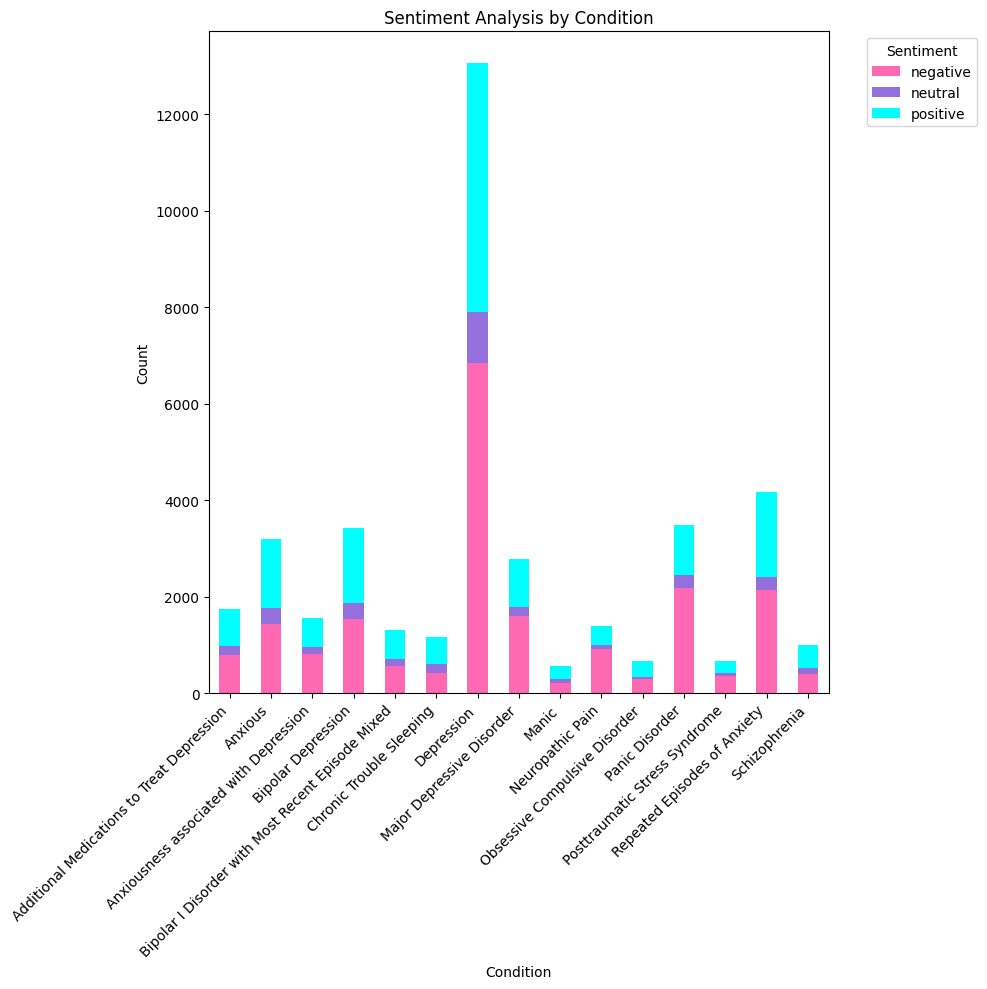

In [ ]:
import matplotlib.pyplot as plt

# Plot condition data
df_condition_pivot.plot(kind='bar', stacked=True, figsize=(10, 10), color=['hotpink', 'mediumpurple', 'cyan'])

plt.title('Sentiment Analysis by Condition')
plt.xlabel('Condition')
plt.ylabel('Count')
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

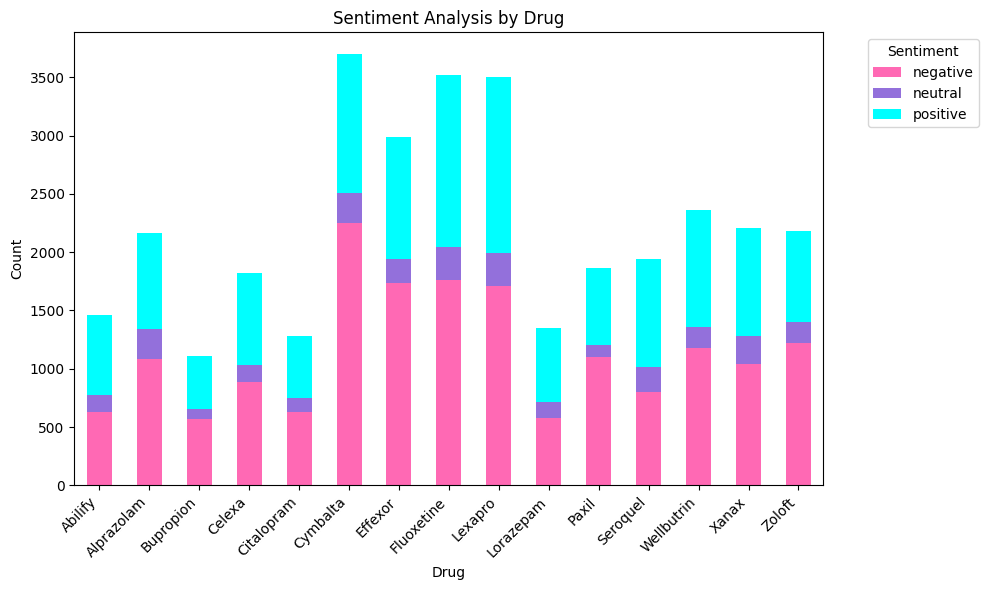

In [ ]:
# Plot drug data
df_drug_pivot.plot(kind='bar', stacked=True, figsize=(10, 6), color=['hotpink', 'mediumpurple', 'cyan'])

plt.title('Sentiment Analysis by Drug')
plt.xlabel('Drug')
plt.ylabel('Count')
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

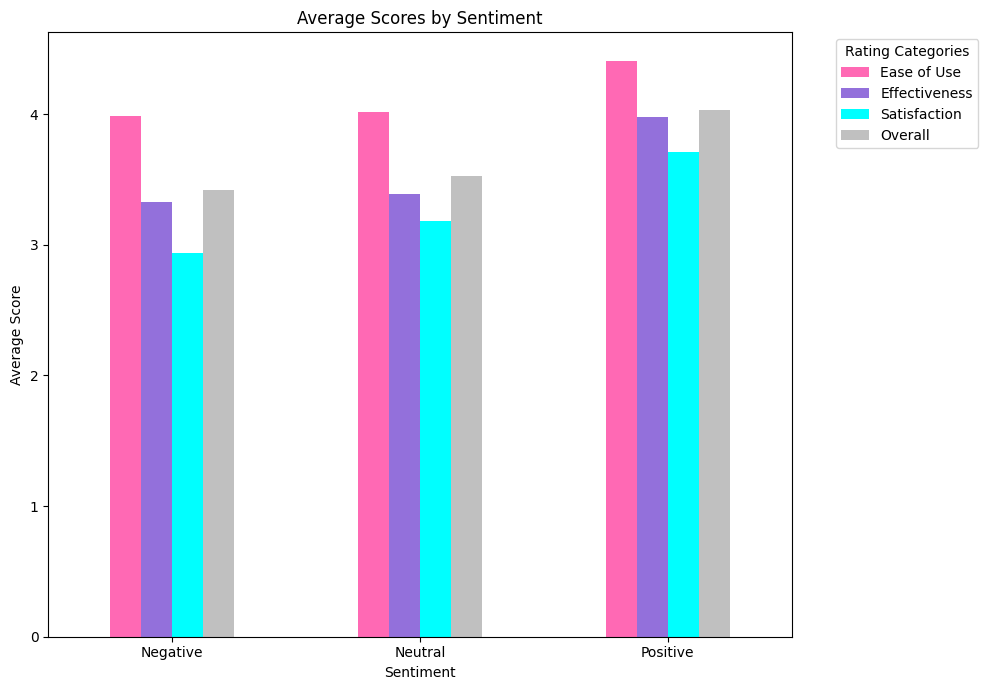

In [ ]:
# Select only the columns that contain the average scores
average_scores = sentiment_summary[['avg_rating_ease_of_use', 'avg_rating_effectiveness',
                                    'avg_rating_satisfaction','avg_rating_overall']]

# Plot the averages for each of the rating categories by sentiment
average_scores.plot(kind='bar', figsize=(10, 7), color=['hotpink', 'mediumpurple', 'cyan', 'silver'])

plt.title('Average Scores by Sentiment')
plt.xlabel('Sentiment')
plt.xticks(ticks=range(len(sentiment_summary)), labels=['Negative', 'Neutral', 'Positive'], rotation=0)
plt.ylabel('Average Score')
plt.legend(title='Rating Categories', bbox_to_anchor=(1.05, 1), loc='upper left',
           labels=['Ease of Use', 'Effectiveness', 'Satisfaction', 'Overall'])
plt.tight_layout()

plt.show()